## Day-3:S-1

Brian2 Tutorials

In [9]:
import brian2 as b
import matplotlib.pyplot as plt

In [8]:
from brian2 import *

In [10]:
tau = 10*ms
eqs ='''
dv/dt =(1-v)/tau : 1
'''

In Brian, we only create groups of neurons, using the class NeuronGroup. The first two arguments when we create one of these objects are the number of neurons (in this case, 1) and the defining differential equations.

In [12]:
G = NeuronGroup(1,eqs)
run(100*ms)

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\abhia\AppData\Local\Temp\ipykernel_192\2507463238.py', line 1, in <module>
    G = NeuronGroup(1,eqs) [brian2.core.base.unused_brian_object]
INFO       No numerical integration method specified for group 'neurongroup_1', using method 'exact' (took 0.03s). [brian2.stateupdaters.base.method_choice]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this w

In [13]:
start_scope()

G= NeuronGroup(1,eqs, method= "exact")
print('Before v = %s' % G.v[0])
run(100*ms)
print('After v = %s' % G.v[0])

Before v = 0.0
After v = 0.9999546000702376


In [14]:
print('Expected value of v = %s' % (1-exp(-100*ms/tau)))

Expected value of v = 0.9999546000702375


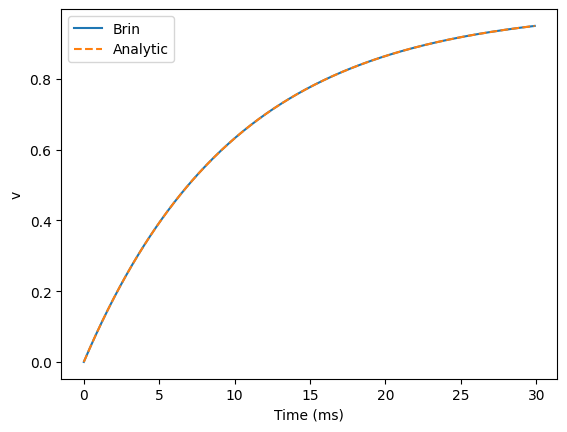

In [17]:
start_scope()

G= NeuronGroup(1,eqs,method='exact')
M= StateMonitor(G, 'v', record=True)

run(30*ms)

plot(M.t/ms, M.v[0], label ='Brin')
plot(M.t/ms, 1-exp(-M.t/tau), 'C1--',label='Analytic')
xlabel('Time (ms)')
ylabel('v');
legend();

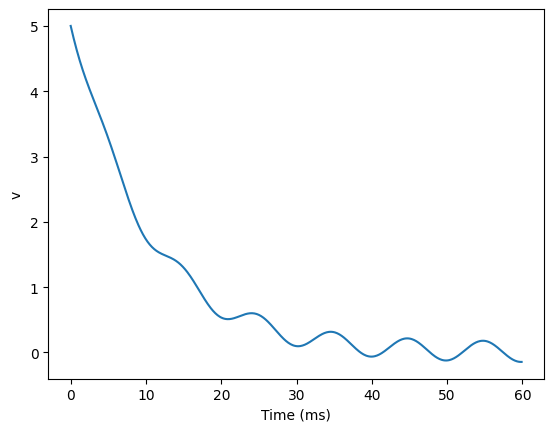

In [18]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (sin(2*pi*100*Hz*t)-v)/tau : 1
'''

# Change to Euler method because exact integrator doesn't work here
G = NeuronGroup(1, eqs, method='euler')
M = StateMonitor(G, 'v', record=0)

G.v = 5 # initial value

run(60*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

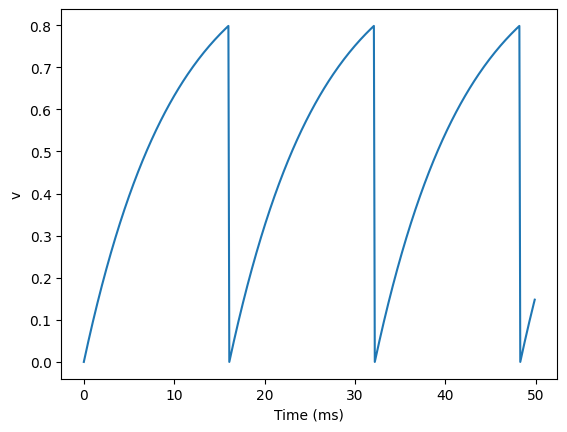

In [19]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', method='exact')

M = StateMonitor(G, 'v', record=0)
run(50*ms)
plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

In [20]:
start_scope()

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', method='exact')

spikemon = SpikeMonitor(G)

run(50*ms)

print('Spike times: %s' % spikemon.t[:])

Spike times: [16.  32.1 48.2] ms


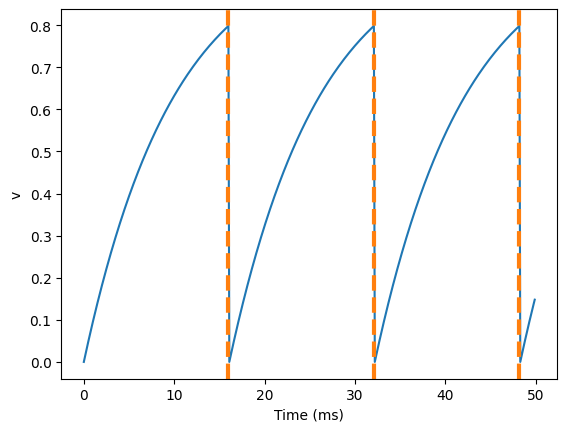

In [21]:
start_scope()

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', method='exact')

statemon = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)

run(50*ms)

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
xlabel('Time (ms)')
ylabel('v');